# **Exploring the Housing Market in Ames, Iowa**

## **Goal**

## **Introduction**

The housing market affects everyone, from big real estate investors to families looking for a home. It's a complicated system, with prices and trends shifting constantly over time. In this report, we aim to make sense of these changes and provide a clearer picture of how the market has evolved. To do this, we'll analyze data from 1,460 property sales recorded between 2006 and 2010. Within this dataset, our focus will be on....


The data was collected by De Cock and recorded 1460 properties in Ames, IA.

Brief description of columns:

**1. Identification**
- **Id:** Property ID (unique identifier).

__2. Sale Information__
- **SalePrice:** Target variable — final selling price.
- **MoSold:** Month sold.
- **YrSold:** Year sold.

__3. Lot & Land__
- **MSSubClass:** Dwelling type (e.g., 1-story, 2-story).
- **MSZoning:** Zoning classification.
- **LotArea:** Lot size (sq ft).

__4. Building & Construction__

- **BldgType:** Building type (Single-family, Duplex).
- **HouseStyle:** House style (1-story, 2-story, split-level).
- **YearBuilt:** Year built.
- **Exterior1st/Exterior2nd:** Exterior covering materials.
- **MasVnrType:** Masonry veneer type.
- **ExterQual:** Exterior quality.
- **ExterCond:** Exterior condition.

__5. Interior Features__

- **GrLivArea:** Above-ground living area.
- **BsmtFullBath/BsmtHalfBath:** Basement bathrooms.
- **FullBath/HalfBath:** Bathrooms above ground.
- **BedroomAbvGr:** Bedrooms above ground.
- **TotRmsAbvGrd:** Total rooms above ground.



**This dataset represents the sale of properties in Ames, Iowa, where every single record represents a sale of individual house.
There are identification, land lot information, house characteristics, exterior, sales information and other features describing each house. The data of selling houses spans from 2006 to 2010.**

### __Import Libraries__

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
import sidetable
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS
import statsmodels.api as sm

### __Display Setting__

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
import warnings
warnings.filterwarnings("ignore")
# set the decimal places to 2
pd.set_option("display.float_format", "{:.2f}".format)

### **Basic Understanding & Data Ingestion**

In [25]:
path = Path.cwd().parent
data_path = path.joinpath("data", "raw")
files = []
for file in data_path.rglob("*.csv"):
    files.append(file)
    print(file.name)
    print(files.index(file), " ", file)

sample_submission.csv
0   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\sample_submission.csv
test.csv
1   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\test.csv
train.csv
2   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\train.csv


In [61]:
# Read train and test
train_data = pd.read_csv(files[2])
test_data = pd.read_csv(files[1])
print("Training Dataset:")
display(df_train.head(1))
print("\n")
print("Testing Dataset:")
display(df_test.head(1))


Training Dataset:


,Id,MSSubClass,MSZoning,LotArea,BldgType,HouseStyle,YearBuilt,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,MoSold,YrSold,SalePrice
0,1,60,RL,8450,1Fam,2Story,2003,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,1710,1,0,2,1,3,8,2,2008,208500




Testing Dataset:


,Id,MSSubClass,MSZoning,LotArea,BldgType,HouseStyle,YearBuilt,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,MoSold,YrSold
0,1461,20,RH,11622,1Fam,1Story,1961,VinylSd,VinylSd,NaN,0.00,TA,TA,896,0.00,0.00,1,0,2,5,6,2010


In [62]:
# Basic info of datasets
print(f"Training Dataset Shape : {train_data.shape}")
print(f"Testing Dataset Shape : {test_data.shape}")


Training Dataset Shape : (1460, 81)
Testing Dataset Shape : (1459, 80)


In [63]:
# remove whitespace from columns name, replace space to '_' for columns name for conveince

train_data.columns = train_data.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")#.str.lower()
test_data.columns = test_data.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

In [64]:
# Selecting columns for analysis in this notebook and define new train and test datasets
cols = ['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'BldgType',
    'HouseStyle', 'YearBuilt', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
    'MasVnrArea', 'ExterQual', 'ExterCond', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
    'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'MoSold', 'YrSold', 'SalePrice']
    
df_train = train_data[cols]


In [65]:
new_cols = [x for x in cols if x != "SalePrice"]
df_test = test_data[new_cols]

### **Columns Formatting and Consistency**

In [66]:
dtype_df = pd.DataFrame(index=df_train.columns, columns=['Dtype','nunique','unique'])
dtype_df['Dtype'] = df_train.dtypes
dtype_df['nunique'] = df_train.nunique()
dtype_df['unique'] = [df_train[col].unique() for col in df_train.columns]
dtype_df


,Dtype,nunique,unique
Id,int64,1460,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
MSSubClass,int64,15,"[60, 20, 70, 50, 190, 45, 90, 120, 30, 85, 80,..."
MSZoning,object,5,"[RL, RM, C (all), FV, RH]"
LotArea,int64,1073,"[8450, 9600, 11250, 9550, 14260, 14115, 10084,..."
BldgType,object,5,"[1Fam, 2fmCon, Duplex, TwnhsE, Twnhs]"
HouseStyle,object,8,"[2Story, 1Story, 1.5Fin, 1.5Unf, SFoyer, SLvl,..."
YearBuilt,int64,112,"[2003, 1976, 2001, 1915, 2000, 1993, 2004, 197..."
Exterior1st,object,15,"[VinylSd, MetalSd, Wd Sdng, HdBoard, BrkFace, ..."
Exterior2nd,object,16,"[VinylSd, MetalSd, Wd Shng, HdBoard, Plywood, ..."
MasVnrType,object,3,"[BrkFace, nan, Stone, BrkCmn]"


### **Exploratory Data Analysis with Charts**

Let's explore the questions that were outlined in the goal section:



In [ ]:
['BedroomAbvGr', 'FullBath', 'GrLivArea','HalfBath', 'Id', 'LotArea', 'MSSubClass', 'TotRmsAbvGrd']

Index(['BedroomAbvGr', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'GrLivArea',
       'HalfBath', 'Id', 'LotArea', 'MSSubClass', 'MasVnrArea', 'MoSold',
       'TotRmsAbvGrd', 'YearBuilt', 'YrSold'],
      dtype='object')

In [68]:
# Create a new column for decade bins
df_train["DecadeBuilt"] = (df_train['YearBuilt']//10)*10

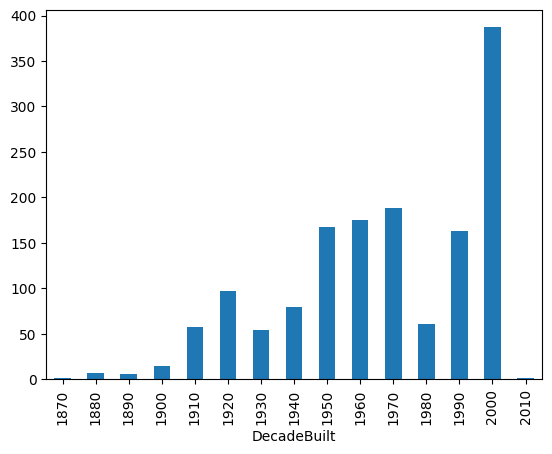

In [118]:
df_train.groupby(['DecadeBuilt']).size().plot(kind='bar');

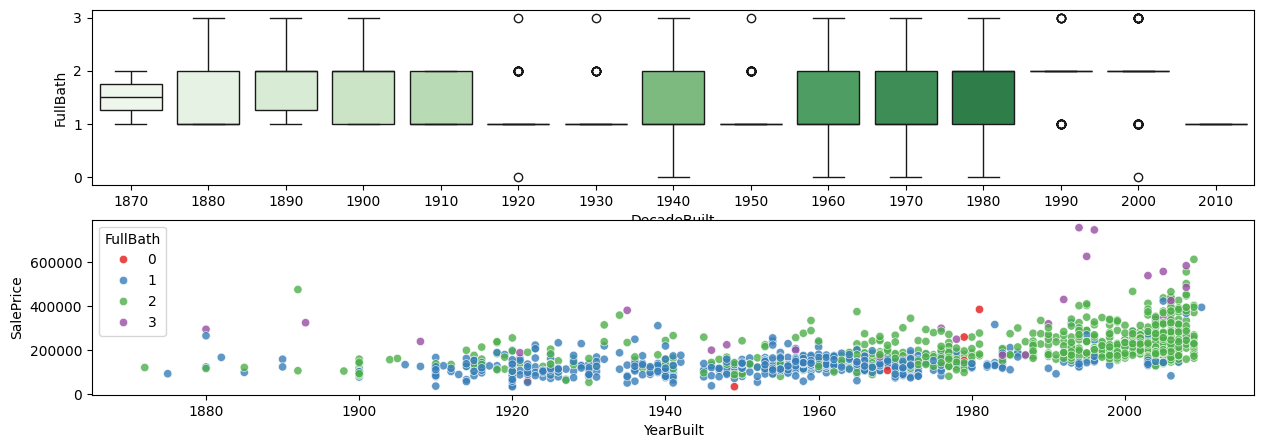

In [136]:
u = df_train.groupby(['DecadeBuilt'])["FullBath"].count().reset_index()
fig, ax = plt.subplots(2, 1,figsize=(15, 5))
sns.boxplot(data=df_train, x="DecadeBuilt", y="FullBath", palette='Greens', ax=ax[0])

sns.scatterplot(
    data=df_train,
    x="YearBuilt",
    y="SalePrice",
    hue="FullBath",   # color by overall quality
    #hue_order=range(1, 11),
    alpha=0.8,
    palette=sns.color_palette("Set1", 4)  
);

In [128]:
df_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'BldgType', 'HouseStyle',
       'YearBuilt', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
       'FullBath', 'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'MoSold',
       'YrSold', 'SalePrice', 'DecadeBuilt'],
      dtype='object')

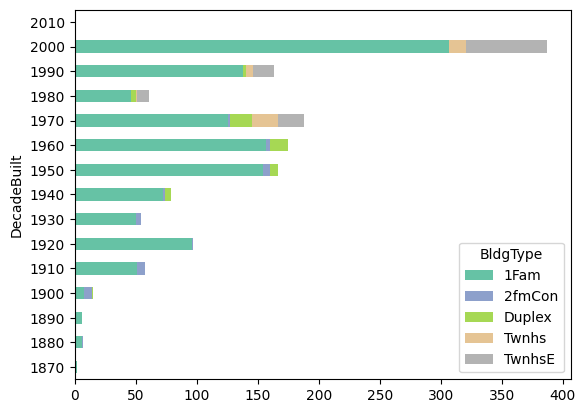

In [145]:
df_train.groupby(['DecadeBuilt', 'BldgType']).size().unstack(fill_value=0).plot(kind='barh', colormap="Set2", stacked=True);

In [ ]:
u = df_train.groupby(['BldgType']).agg(
    avg_rooms = ('TotRmsAbvGrd', 'mean'),
    avg_bed_rooms = ('BedroomAbvGr', 'mean')
).reset_index()
u

,BldgType,avg_rooms,avg_bed_rooms
0,1Fam,6.60,2.93
1,2fmCon,7.23,3.35
2,Duplex,7.69,3.56
3,Twnhs,5.56,2.37
4,TwnhsE,5.24,1.95


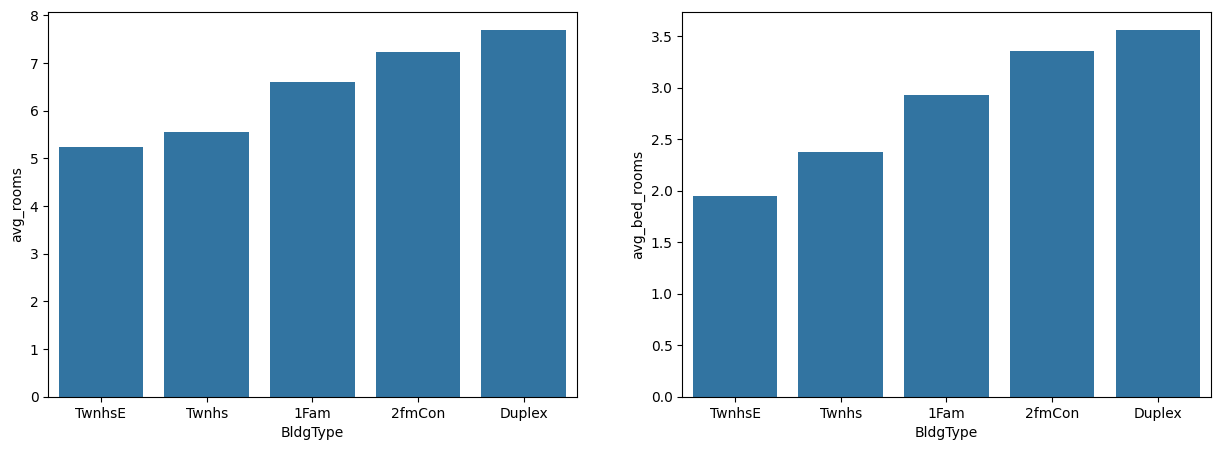

In [155]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=u.sort_values(by='avg_rooms', ascending=True), x='BldgType', y='avg_rooms', ax=ax[0])
sns.barplot(data=u.sort_values(by='avg_bed_rooms', ascending=True), x='BldgType', y='avg_bed_rooms', ax=ax[1]);

In [157]:
v = df_train.groupby(['HouseStyle']).agg(
    avg_rooms = ('TotRmsAbvGrd', 'mean'),
    avg_bed_rooms = ('BedroomAbvGr', 'mean')
).reset_index()
v

,HouseStyle,avg_rooms,avg_bed_rooms
0,1.5Fin,6.71,3.08
1,1.5Unf,4.71,2.07
2,1Story,5.90,2.59
3,2.5Fin,10.62,4.62
4,2.5Unf,8.27,3.27
5,2Story,7.58,3.29
6,SFoyer,4.89,2.05
7,SLvl,6.23,2.89


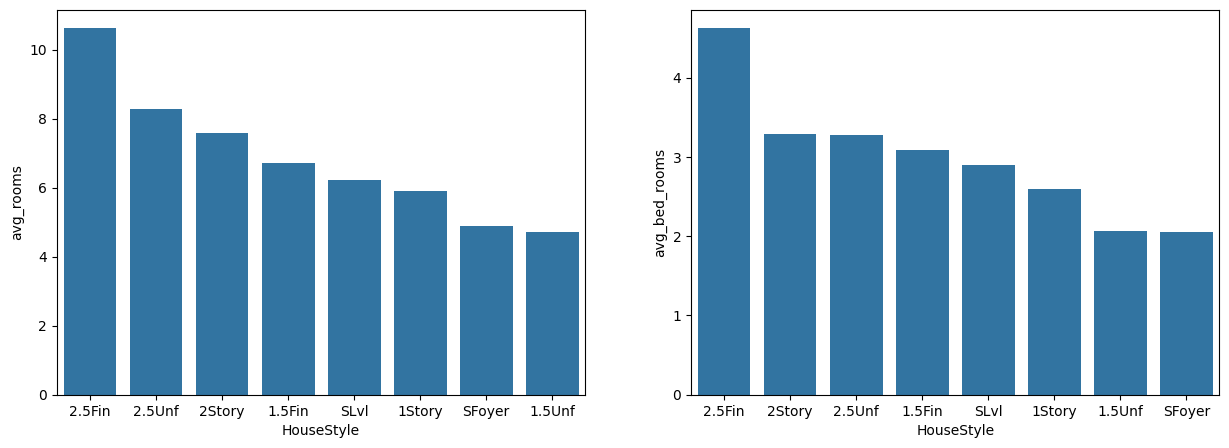

In [158]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=v.sort_values(by="avg_rooms", ascending=False), x='HouseStyle', y='avg_rooms', ax=ax[0])
sns.barplot(data=v.sort_values(by='avg_bed_rooms', ascending=False), x='HouseStyle', y='avg_bed_rooms', ax=ax[1]);

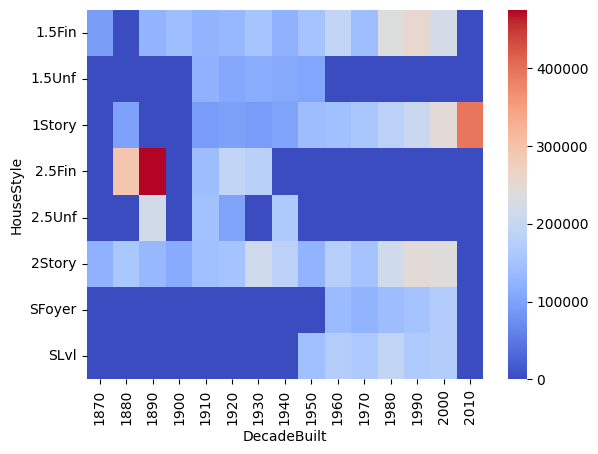

In [184]:
j= df_train.pivot_table(index='HouseStyle', columns='DecadeBuilt', values='SalePrice', aggfunc='mean').fillna(0)
sns.heatmap(j, cmap='coolwarm');

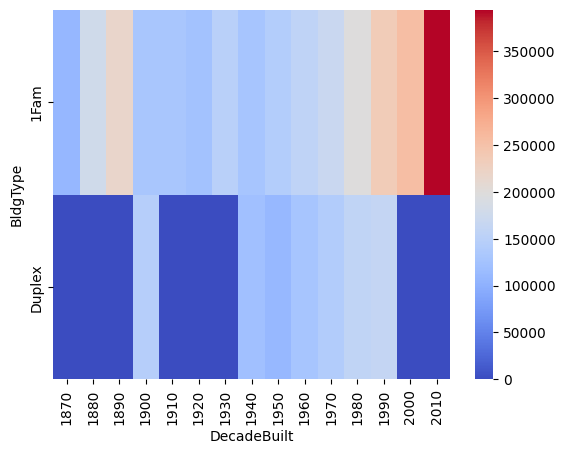

In [182]:
k= df_train.query("BldgType.isin(['1Fam', 'Duplex'])").pivot_table(index='BldgType', columns='DecadeBuilt', values='SalePrice', aggfunc='mean').fillna(0)
sns.heatmap(k, cmap='coolwarm');

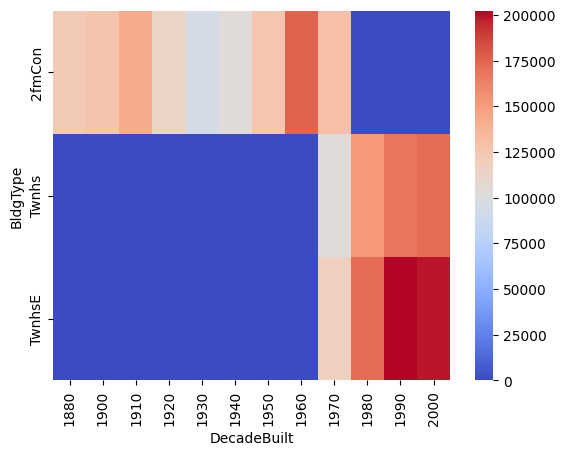

In [183]:
k= df_train.query("BldgType.isin(['TwnhsE', 'Twnhs', '2fmCon'])").pivot_table(index='BldgType', columns='DecadeBuilt', values='SalePrice', aggfunc='mean').fillna(0)
sns.heatmap(k, cmap='coolwarm');

In [180]:
df_train['BldgType'].value_counts()

BldgType
1Fam      1220
TwnhsE     114
Duplex      52
Twnhs       43
2fmCon      31
Name: count, dtype: int64

In [159]:
df_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'BldgType', 'HouseStyle',
       'YearBuilt', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
       'FullBath', 'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'MoSold',
       'YrSold', 'SalePrice', 'DecadeBuilt'],
      dtype='object')